# Week 1: System exploration (Group)

In the first stage, your aim is to **understand the behaviour of a system**.

You should focus on questions like:
- How do the observed signals change over time?
- How do different input patterns affect the observations?
- Are some signals more informative than others?
- What is easy to observe, and what seems hidden?

At this stage, the priority is **exploration and intuition-building**, not solving the whole project.

## Group tasks for Week 1

As a group, extend the basic experiment and **build a shared code workflow.**

Your group should aim to produce:
- a clean way to explore dataset, either from simulation or experiment,
- standard plotting functions,
- a simulation platform for studying and comparing effects of different input patterns and system dynamics (transition matrices), for example:
    - random inputs,
    - pulses,
    - oscillatory inputs,
    - activating only one input channel at a time,
    - activating different channels with different amplitudes,
    - exploring the relationship between input structure and system dynamics (such as coupling between inputs and transition matrices);
- brief documentation so that all group members can build on the same starting point.

All of the above tasks should be completed by Friday 22 May, before the scheduled check-in session.

## Week 1 deliverable

**Deliverable:** Group simulation code + brief documentation  
**Marks:** 10 group marks  
**Due:** Friday 22 May, 11am–1pm (**compulsory session**)

At the check-in session, the demonstrator will review the code and ask each member of the group questions about it. Every member of the group is therefore expected to have contributed to the code and to take full responsibility for understanding it.

## Example dataset

In [25]:
# loading dataset
import numpy as np
data = np.load("ExampleDataset.npy")
print("Dataset loaded successfully. Shape:", data.shape)  # (Trials, Timepoints, Neurons)

Dataset loaded successfully. Shape: (5, 60, 16)


## Desgin an illustrator

A class that can generate primary statistics, analyses, and visualization of any dataset. Design your illustrator in **Illustrator.py**.

To test your documentation, the demonstrator will use your illustrator here, but will never see your code (in this section). 

Please make your annotations clear and comprehensive!

In [26]:
from Illustrator import Illustrator

Illustrator = Illustrator(data)

pass

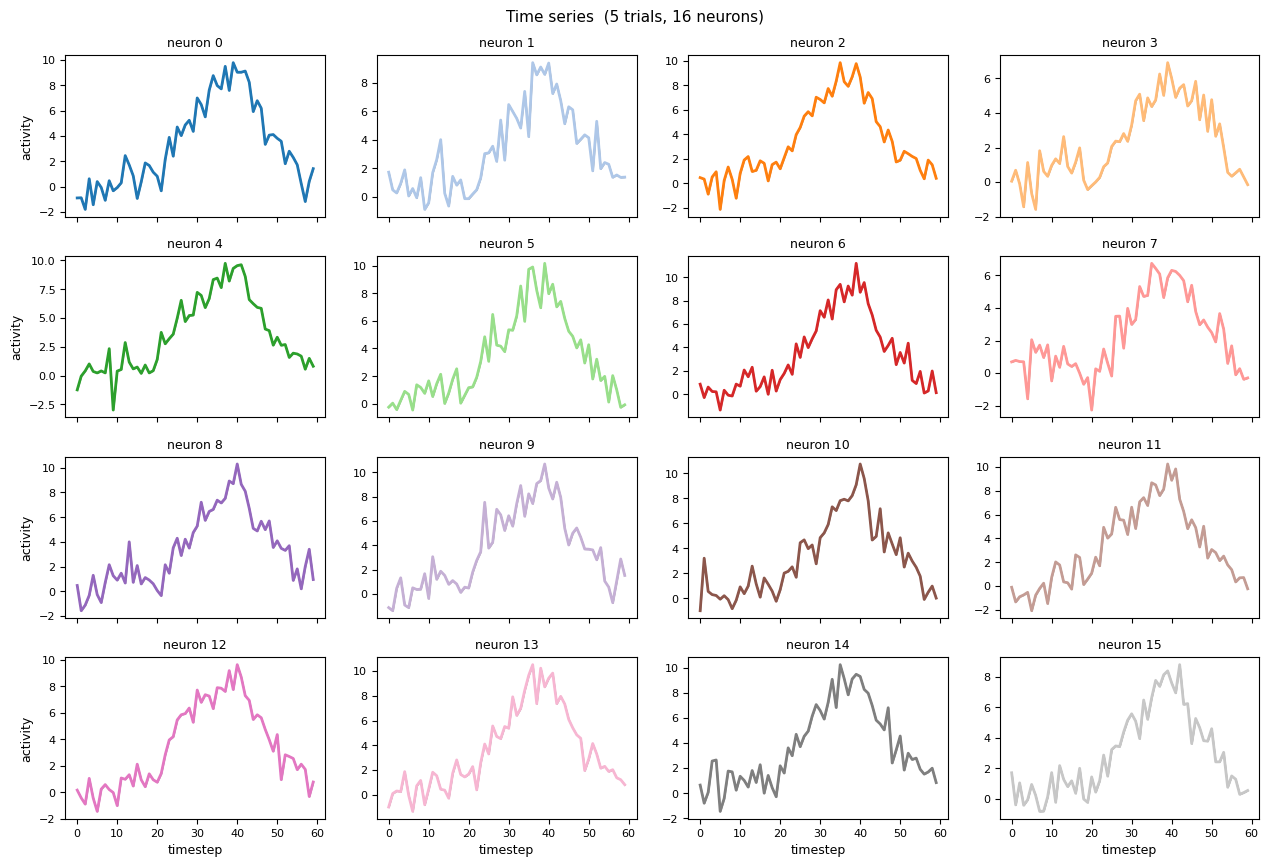

In [27]:
import matplotlib.pyplot as plt

Illustrator.plot_timeseries()
plt.show()

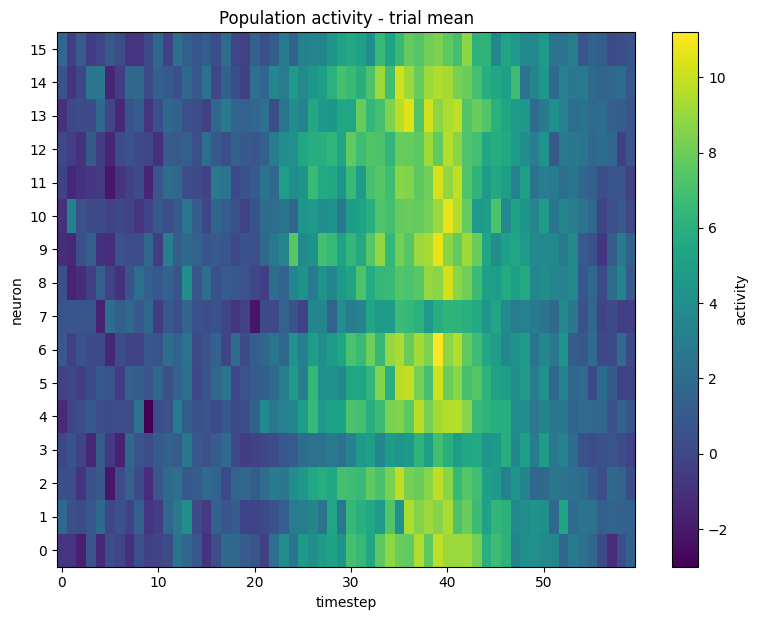

In [28]:
Illustrator.plot_heatmap()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


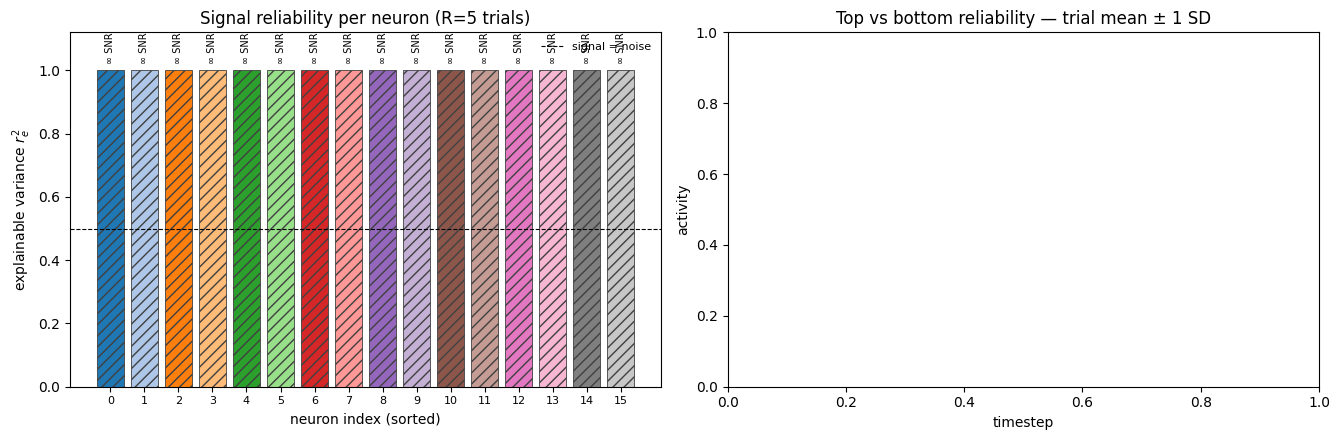

In [29]:
snr, fig = Illustrator.compute_snr(plot=True)
plt.show()

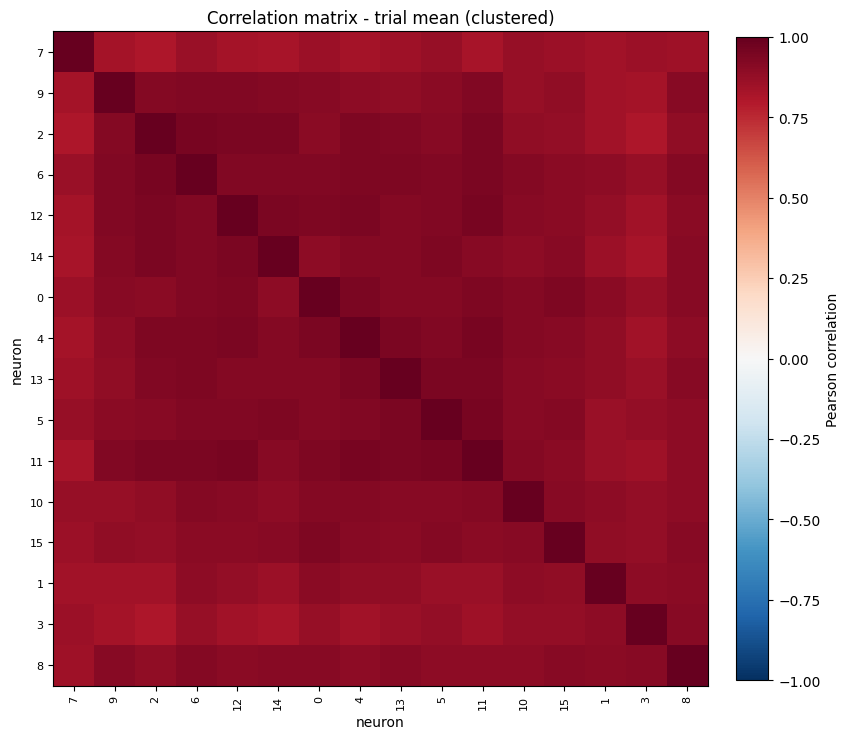

In [30]:
C, fig = Illustrator.plot_correlation_matrix()
plt.show()

## Design a simulator

In GG4, we use a simple linear model:
$$
x_{t+1} = Ax_t + Bu_t + w_t, w_t \sim \mathcal{N}(0, Q)
$$
$$
y_t = Cx_t + o_t, o_t \sim \mathcal{N}(0, R)
$$

Your simulator should be able to simulate observation of any length given different parameters.

Design your simulator in **Simulator.py**.

To test your documentation, the demonstrator will use your simulator here, but will never see your code (in this section). 
Please make your annotations clear and comprehensive!

Combining the illustrator and simulator, what's your findings? Illustrate them.
This forms your answer to the question: "effects of different input patterns and system dynamics"

In [31]:
import Simulator as sim

In [32]:
import matplotlib.pyplot as plt

system = sim.default_neural_system(seed=0)
T = 60
n = system.state_dim

print(f"States: {n}  |  Inputs: {system.input_dim}  |  Observations: {system.obs_dim}")
print(f"Stable:       {(np.abs(np.linalg.eigvals(system.A)) < 1).all()}")
print(f"Controllable: {sim.matrix_rank(sim.controllability_matrix(system.A, system.B)) == n}")
print(f"Observable:   {sim.matrix_rank(sim.observability_matrix(system.A, system.C)) == n}")

States: 4  |  Inputs: 2  |  Observations: 16
Stable:       True
Controllable: True
Observable:   True


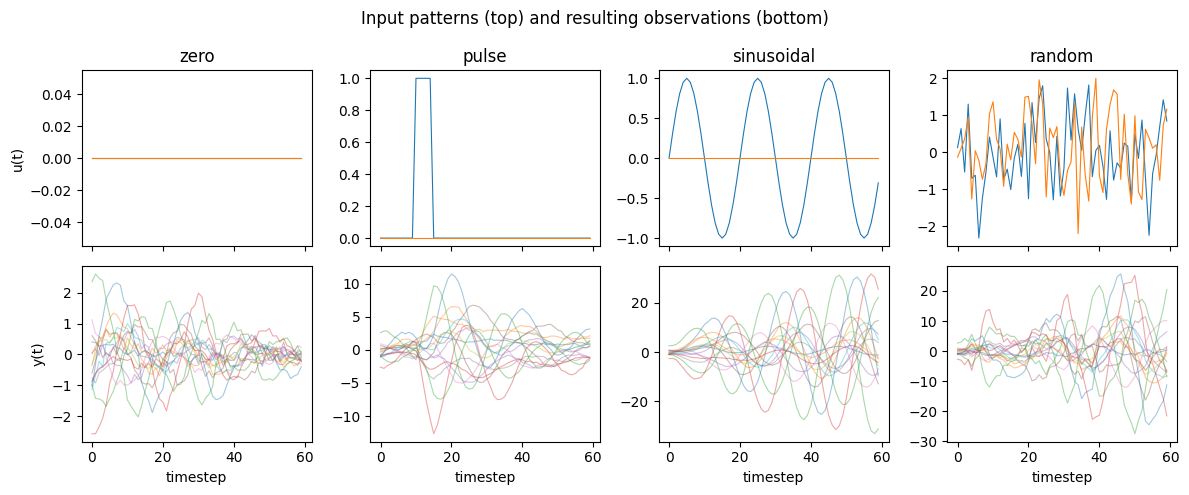

In [33]:
inputs = {
    "zero":       sim.zero_input(T, system.input_dim),
    "pulse":      sim.pulse_input(T, system.input_dim, start=10, duration=5),
    "sinusoidal": sim.sinusoidal_input(T, system.input_dim, period=20.0),
    "random":     sim.random_input(T, system.input_dim, seed=0),
}

fig, axes = plt.subplots(2, len(inputs), figsize=(12, 5), sharex=True)
for col, (name, u) in enumerate(inputs.items()):
    result = system.simulate(T, U=u)
    axes[0, col].plot(u, lw=0.8)
    axes[0, col].set_title(name)
    if col == 0:
        axes[0, col].set_ylabel("u(t)")
        axes[1, col].set_ylabel("y(t)")
    axes[1, col].plot(result["y"], alpha=0.4, lw=0.8)
    axes[1, col].set_xlabel("timestep")
fig.suptitle("Input patterns (top) and resulting observations (bottom)")
plt.tight_layout()
plt.show()

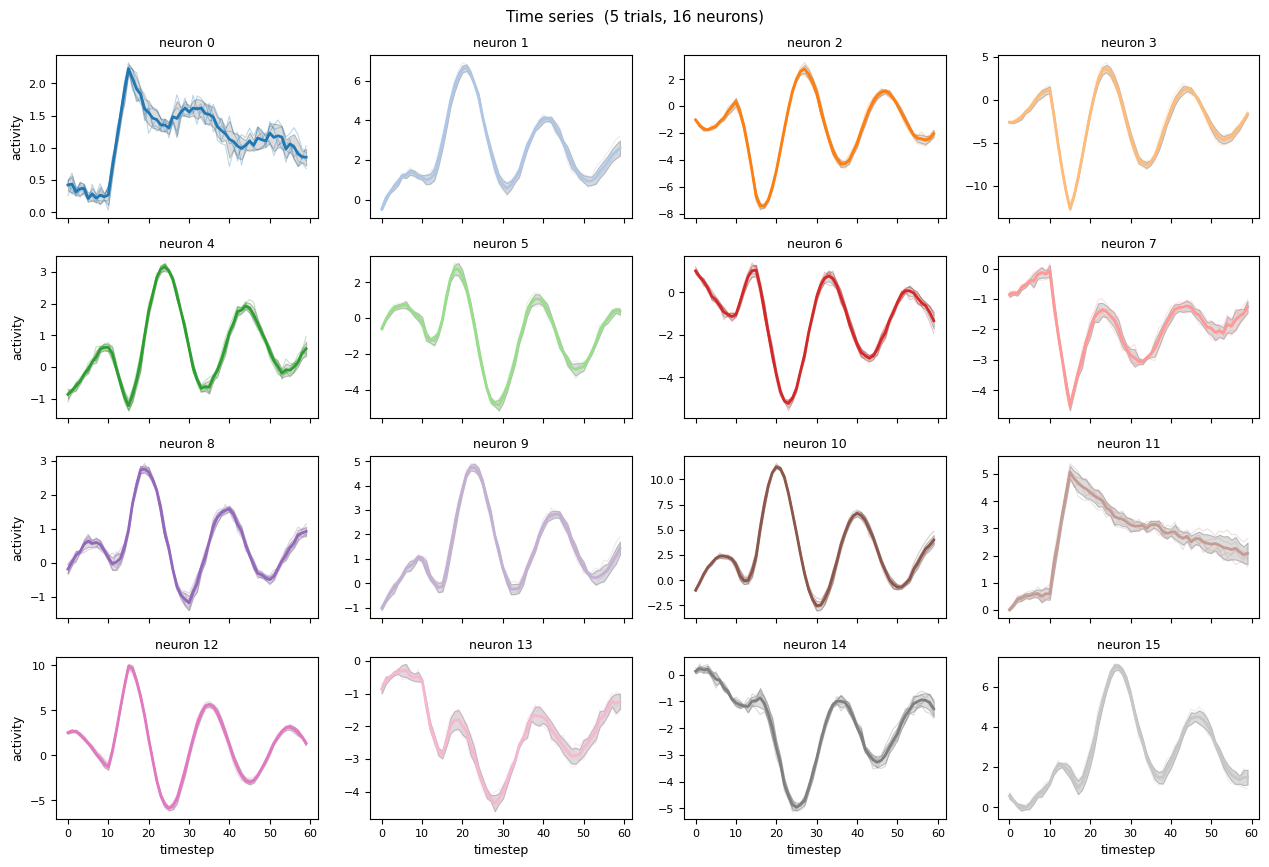

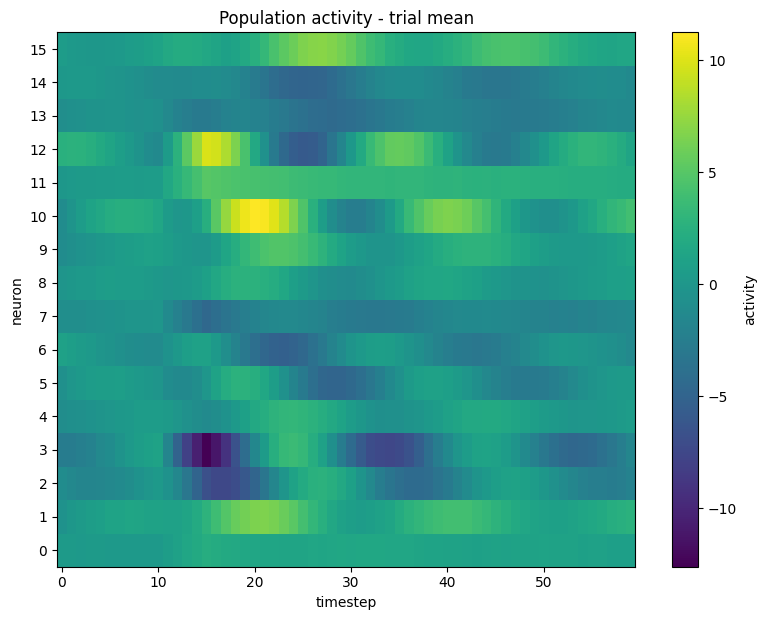

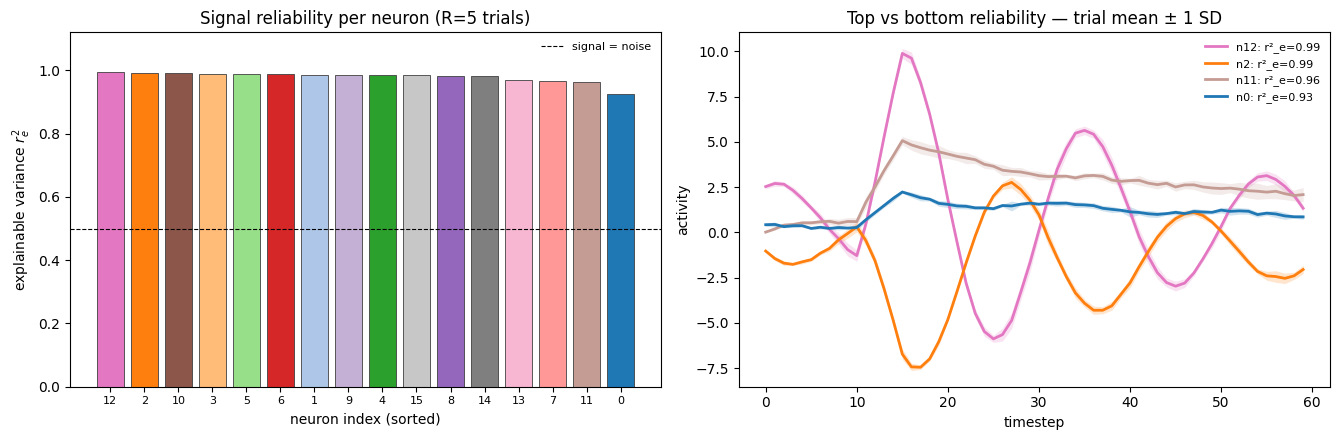

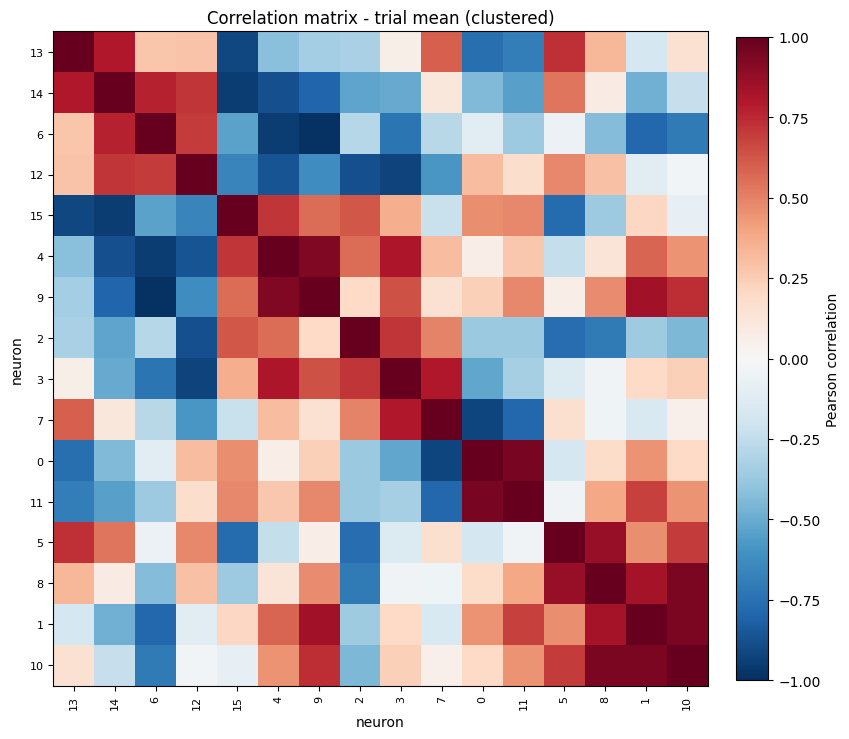

In [34]:
from Illustrator import Illustrator as IllustratorClass

trials = system.simulate_trials(5, T, U=inputs["pulse"])
sim_illus = IllustratorClass(trials["y"])

sim_illus.plot_timeseries()
plt.show()

sim_illus.plot_heatmap()
plt.show()

snr, fig = sim_illus.compute_snr(plot=True)
plt.show()

C, fig = sim_illus.plot_correlation_matrix()
plt.show()